In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


(3599, 74, 119)
(3599, 74, 119)
[                                        ]0%Filter Frequency = 0.3759Hz
(3599, 74, 119)
[######                                  ]15%Filter Frequency = 0.3464Hz
(3599, 74, 119)
[###########                             ]29%Filter Frequency = 0.3064Hz
(3599, 74, 119)
[#################                       ]43%Filter Frequency = 0.2571Hz
(3599, 74, 119)
[############################            ]72%Filter Frequency = 0.1368Hz
(3599, 74, 119)
[##################################      ]86%Filter Frequency = 0.0695Hz
(3599, 74, 119)
Elapsed time: 188.602513 seconds.



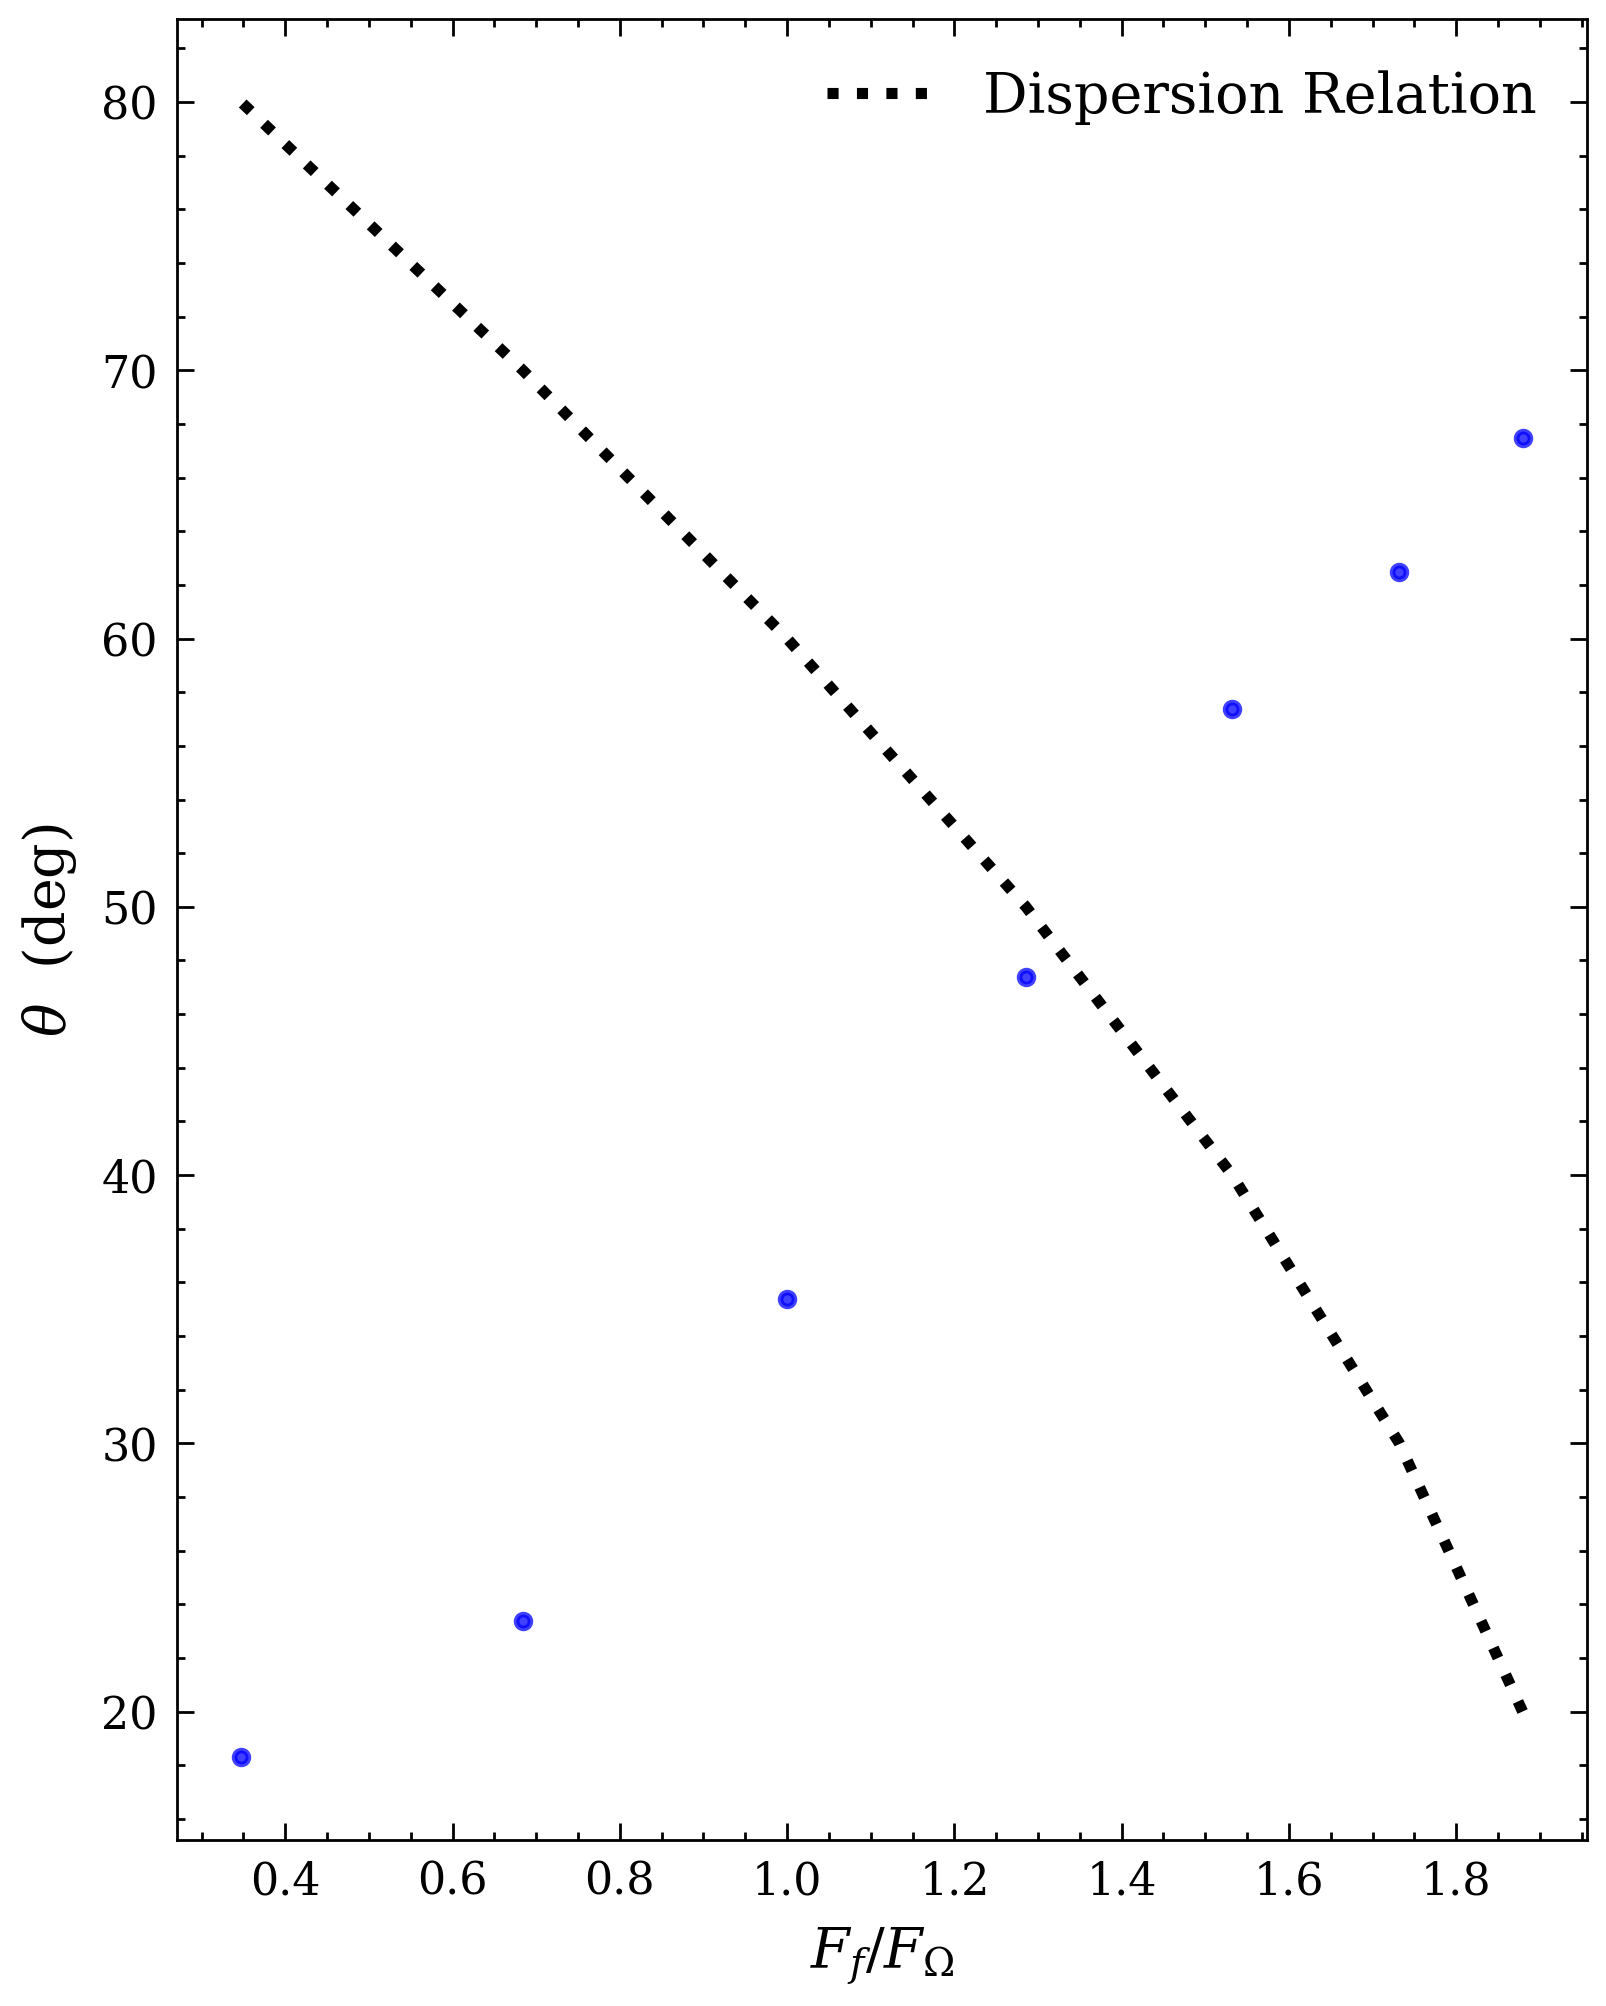

In [ ]:
h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
Vels = ['U200']
Len = ['L100']
RPMs = ['RPM0', 'RPM3' ,'RPM6', 'RPM9', 'RPM12']

vels = h5file['Wide'][Vels[0]][Len[0]][RPMs[4]]
u = vels[:,:,:,0]
v = vels[:,:,:,1]

# u = np.mean(u, axis=0)
# u = u[1500,:,:]
# v = np.mean(v, axis=0)
# v = v[1500,:,:]

fps = np.array([60], dtype=int)
PRPM = np.array([2, 4, 8, 16, 32], dtype=int)
vel0 = 0.01162 * PRPM / 2
q0 = 0.000000329 * PRPM / 2

rpm = np.array([0, 1, 2, 3, 6, 9, 12])
RealRpm = np.array([0, 1, 2, 3, 6, 9, 12])

nRot = rpm.shape[0]
nInj = PRPM.shape[0]

d = 0.05

f1, ax1s = plt.subplots(nrows=1, ncols=1, figsize = (4, 5))

r, z = oj.NDUnitsForPlotsWide(u.shape[0], u.shape[1])
X, Y = np.meshgrid(r, z)

# Angles = np.linspace(10, 80, dtype='int')
Angles= np.array([20, 30, 40, 50, 60, 70, 80])
# Angles= np.array([60, 70])


left  = int(u.shape[1]/2)###############Temp line
right = int(u.shape[1]-(u.shape[1]/2))###############Temp line
# print(left, right)


## Import flow field 
runRot = 6
runInj = 1
# data = h5file['Narrow'][Vels[0]][Len[0]]['RPM{0}'.format(rpm[runRot])]
# data = h5file['RPM{0}'.format(rpm[runRot])]['INJ{0}'.format(PRPM[runInj])]
data = h5file['Wide'][Vels[0]][Len[0]]['RPM12']

uTemp = data[:, :, : ,0] #* mask #/ vel0[runInj]
vTemp = data[:, :, : ,1] #* mask #/ vel0[runInj]
h5file.close()

# v = np.mean(v, axis=0)
# u = uTemp[1500,:,:]
# v = vTemp[1500,:,:]
uTrans = np.transpose(uTemp, (0, 2, 1))
vTrans = np.transpose(vTemp, (0, 2, 1))
# print(uTrans.shape)
# break

# uTemp = np.rot90(u, 1)###############Temp line
vTemp = v###############Temp line
print(u.shape)
print(uTemp.shape)

# plt.contourf(np.rot90(u, 1))
# plt.contourf(uTemp[:,500,:])
# plt.show()

vmean = np.mean(vTemp, axis=0)
# vmean = np.mean(uTemp, axis=0) ###############Temp line
angMean = np.zeros(Angles.shape[0])
oj.tic()
for i in range(Angles.shape[0]):
    oj.progressBar(i, Angles.shape[0])
    ang = Angles[i]
    # print(ang)

    if ang == 60:
        angMean[i] = 0 
    else:
        IWsF = oj.IWFilter(uTrans, ang, fps=60, rpm = 12)#, phase = 1)
        # IWsF = oj.IWFilter(vTrans, ang, fps=60, rpm = 12)#, phase = 1)
        # IWsF = oj.IWFilter(uTemp, ang, fps=fps[runInj], rpm = RealRpm[runRot])###############Temp line
        print(IWsF.shape)

        Al,Bl,Cl,Dl,El,Fl,angDL = oj.TwoPtCorrIWs(IWsF[:, 2:, :left])
        Ar,Br,Cr,Dr,Er,Fr,angDR = oj.TwoPtCorrIWs(IWsF[:, 2:, right:])
        # print(angDL, angDR)
        angD = (angDL+angDR)/2
        angMean[i] = angD
angMean = oj.InterpZeros(angMean)

oj.toc()

FByOmega = 2 * np.cos(np.deg2rad(Angles)) 

ax1s.plot(FByOmega, Angles, linestyle="dotted", color = 'black', label = 'Dispersion Relation')
ax1s.plot(FByOmega, angMean, color='blue', linestyle="none", marker=".", markersize=5, alpha=0.75)#, label = 'Ek - {}'.format(np.round(sb.Ek(RealRpm[runRot]), 4)))
ax1s.legend()

plt.setp(ax1s, xlabel=r'$F_{f} / F_{\Omega}$')
plt.setp(ax1s, ylabel=r"$\theta$  (deg)")

plt.show()

In [ ]:
f1, ax1s = plt.subplots(nrows=1, ncols=1, figsize = (4, 5))
f2, ax2s = plt.subplots(nrows=1, ncols=1, figsize = (6, 4))
# f3, ax3s = plt.subplots(nrows=1, ncols=1, figsize = (6, 4))

distArray = np.zeros(Angles.shape[0])
FFArray = np.zeros(Angles.shape[0])

for i in range(Angles.shape[0]):
    oj.progressBar(i, Angles.shape[0])
    ang = Angles[i]
    FFArray = oj.FiltFreqCalc(ang, fps=60, rpm=12)

    if ang == 60:
        angMean[i] = 0 
        distArray[i] = 0 
    else:
        # IWsF = oj.IWFilter(vTemp, ang, fps=fps[runInj], rpm = RealRpm[runRot], phase = 1)
        IWsF = oj.IWFilter(vTrans, ang, fps=60, rpm = 12)

        _,_,_,_,XCL,YCL,angDL = oj.TwoPtCorrIWs(IWsF[:, 2:, :left])
        _,_,_,_,XCR,YCR,angDR = oj.TwoPtCorrIWs(IWsF[:, 2:, right:])
        wlL = XCL * YCL / (np.sqrt(XCL**2 + YCL**2))
        wlR = XCR * YCR / (np.sqrt(XCR**2 + YCR**2))
        distArray[i] =  2 * (wlL + wlR) * 1.05
        angD = (angDL+angDR)/2
        angMean[i] = angD

angMean = oj.InterpZeros(angMean)
distArray = oj.InterpZeros(distArray)

oj.toc()
h5file.close()

FByOmega = 2 * np.cos(np.deg2rad(Angles)) 

ax1s.plot(FByOmega, Angles, linestyle="dotted", color = 'black', label = 'Dispersion Relation')
ax1s.plot(FByOmega, angMean, color='blue', linestyle="none", marker=".", markersize=5, alpha=0.75, label = '')#'Ek - {}'.format(np.round(oj.Ek(RealRpm[runRot]), 4)))
ax1s.legend()

ax2s.plot(FByOmega, distArray, color='blue', linestyle="none", marker=".", markersize=5, alpha=0.75,)

plt.setp(ax1s, xlabel=r'$F_{f} / F_{\Omega}$')
plt.setp(ax1s, ylabel=r"$\theta$  (deg)")

plt.setp(ax2s, xlabel=r'$F_{f} / F_{\Omega}$')
plt.setp(ax2s, ylabel=r"$\lambda$ (m)")

[                                        ]0%Filter Frequency = 0.3759Hz
[######                                  ]15%Filter Frequency = 0.3464Hz
[###########                             ]29%Filter Frequency = 0.3064Hz
[#################                       ]43%Filter Frequency = 0.2571Hz
[############################            ]72%Filter Frequency = 0.1368Hz
